# walmart store sales

Um desafio da modelagem de dados do varejo é a necessidade de tomar decisões com base em um histórico limitado.
Nesta competição de recrutamento, os candidatos recebem dados históricos de vendas de 45 lojas Walmart localizadas em diferentes regiões.
Cada loja possui diversos departamentos, e os participantes devem projetar as vendas de cada departamento em cada loja.
Esta competição é avaliada com base no erro absoluto médio ponderado (EMP).

Arquivos e dados :

    stores.csv: Este arquivo contém informações anonimizadas sobre as 45 lojas, indicando o tipo e o tamanho da loja.
    train.csv: Estes são os dados históricos de treinamento, que abrangem de 05/02/2010 a 01/11/2012. Neste arquivo, você encontrará os seguintes campos:
        Loja - o número da loja
        Dept - o número do departamento
        Data - a semana
        Vendas semanais - vendas para o departamento fornecido na loja fornecida
        IsHoliday - se a semana é uma semana de feriado especial
    test.csv: Este arquivo é idêntico ao train.csv, exceto que omitimos as vendas semanais. Você deve prever as vendas para cada trio de loja, departamento e data neste arquivo
    features.csv: Este arquivo contém dados adicionais relacionados à loja, ao departamento e à atividade regional nas datas informadas. Ele contém os seguintes campos:
        Loja - o número da loja
        Data - a semana
        Temperatura - temperatura média na região
        Fuel_Price - custo do combustível na região
        MarkDown1-5 - dados anonimizados relacionados a descontos promocionais que o Walmart está realizando. Os dados de MarkDown só estão disponíveis após novembro de 2011 e não estão disponíveis para todas as lojas o tempo todo. Qualquer valor ausente é marcado com um NA.
        IPC - índice de preços ao consumidor
        Desemprego - a taxa de desemprego
        IsHoliday - se a semana é uma semana de feriado especial


Por conveniência, os quatro feriados estão nas seguintes semanas no conjunto de dados (nem todos os feriados estão nos dados):

Super Bowl: 12 de fevereiro de 2010, 11 de fevereiro de 2011, 10 de fevereiro de 2012, 8 de fevereiro de 2013
Dia do Trabalho: 10 de setembro de 2010, 9 de setembro de 2011, 7 de setembro de 2012, 6 de setembro de 2013
Ação de Graças: 26 de novembro de 2010, 25 de novembro de 2011, 23 de novembro de 2012, 29 de novembro de 2013
Natal: 31 de dezembro de 2010, 30 de dezembro de 2011, 28 de dezembro de 2012, 27 de dezembro de 2013


In [95]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


import warnings

In [96]:
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format) 
pd.set_option('display.max_columns', None)              
pd.set_option('display.width', None) 

In [97]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

In [98]:
display(train.head(-10))
display(test.head(-10))
display(stores.head())
display(features.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,"24,924.50",False
1,1,1,2010-02-12,"46,039.49",True
2,1,1,2010-02-19,"41,595.55",False
3,1,1,2010-02-26,"19,403.54",False
4,1,1,2010-03-05,"21,827.90",False
...,...,...,...,...,...
421555,45,98,2012-07-20,845.30,False
421556,45,98,2012-07-27,657.63,False
421557,45,98,2012-08-03,516.46,False
421558,45,98,2012-08-10,727.49,False


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False
...,...,...,...,...
115049,45,98,2013-04-19,False
115050,45,98,2013-04-26,False
115051,45,98,2013-05-03,False
115052,45,98,2013-05-10,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,2010-02-12,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,2010-02-19,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False
3,1,2010-02-26,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,False
4,1,2010-03-05,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,False


In [99]:
display(train.info())
display(test.info())
display(stores.info())
display(features.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


None

In [100]:
display(train.describe())
display(test.describe())
display(stores.describe())
display(features.describe())

,Store,Dept,Weekly_Sales
count,"421,570.00","421,570.00","421,570.00"
mean,22.20,44.26,"15,981.26"
std,12.79,30.49,"22,711.18"
min,1.00,1.00,"-4,988.94"
25%,11.00,18.00,"2,079.65"
50%,22.00,37.00,"7,612.03"
75%,33.00,74.00,"20,205.85"
max,45.00,99.00,"693,099.36"


,Store,Dept
count,"115,064.00","115,064.00"
mean,22.24,44.34
std,12.81,30.66
min,1.00,1.00
25%,11.00,18.00
50%,22.00,37.00
75%,33.00,74.00
max,45.00,99.00


,Store,Size
count,45.00,45.00
mean,23.00,"130,287.60"
std,13.13,"63,825.27"
min,1.00,"34,875.00"
25%,12.00,"70,713.00"
50%,23.00,"126,512.00"
75%,34.00,"202,307.00"
max,45.00,"219,622.00"


,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,"8,190.00","8,190.00","8,190.00","4,032.00","2,921.00","3,613.00","3,464.00","4,050.00","7,605.00","7,605.00"
mean,23.00,59.36,3.41,"7,032.37","3,384.18","1,760.10","3,292.94","4,132.22",172.46,7.83
std,12.99,18.68,0.43,"9,262.75","8,793.58","11,276.46","6,792.33","13,086.69",39.74,1.88
min,1.00,-7.29,2.47,"-2,781.45",-265.76,-179.26,0.22,-185.17,126.06,3.68
25%,12.00,45.90,3.04,"1,577.53",68.88,6.60,304.69,"1,440.83",132.36,6.63
50%,23.00,60.71,3.51,"4,743.58",364.57,36.26,"1,176.42","2,727.14",182.76,7.81
75%,34.00,73.88,3.74,"8,923.31","2,153.35",163.15,"3,310.01","4,832.56",213.93,8.57
max,45.00,101.95,4.47,"103,184.98","104,519.54","149,483.31","67,474.85","771,448.10",228.98,14.31


In [101]:
features.head(-10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,2010-02-12,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,2010-02-19,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False
3,1,2010-02-26,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,False
4,1,2010-03-05,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8175,45,2013-04-19,56.27,3.68,"1,399.81",39.89,44.38,60.83,"1,445.05",193.59,8.34,False
8176,45,2013-04-26,50.64,3.62,"1,260.65",NaN,57.52,40.51,"2,476.18",193.59,8.34,False
8177,45,2013-05-03,56.07,3.59,"8,345.40",6.00,92.96,"3,580.32","2,242.24",NaN,NaN,False
8178,45,2013-05-10,58.86,3.58,"4,689.18",440.82,53.09,375.22,"5,738.20",NaN,NaN,False


In [102]:
features[~features['MarkDown1'].isnull()]

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
92,1,2011-11-11,59.11,3.30,"10,382.90","6,115.67",215.07,"2,406.62","6,551.42",218.00,7.87,False
93,1,2011-11-18,62.25,3.31,"6,074.12",254.39,51.98,427.39,"5,988.57",218.22,7.87,False
94,1,2011-11-25,60.14,3.24,410.31,98.00,"55,805.51",8.00,554.92,218.47,7.87,True
95,1,2011-12-02,48.91,3.17,"5,629.51",68.00,"1,398.11","2,084.64","20,475.32",218.71,7.87,False
96,1,2011-12-09,43.93,3.16,"4,640.65",19.00,105.02,"3,639.42","14,461.82",218.96,7.87,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.64,"4,842.29",975.03,3.00,"2,449.97","3,169.69",NaN,NaN,False
8186,45,2013-07-05,77.50,3.61,"9,090.48","2,268.58",582.74,"5,797.47","1,514.93",NaN,NaN,False
8187,45,2013-07-12,79.37,3.61,"3,789.94","1,827.31",85.72,744.84,"2,150.36",NaN,NaN,False
8188,45,2013-07-19,82.84,3.74,"2,961.49","1,047.07",204.19,363.00,"1,059.46",NaN,NaN,False


<Axes: xlabel='Store', ylabel='Weekly_Sales'>

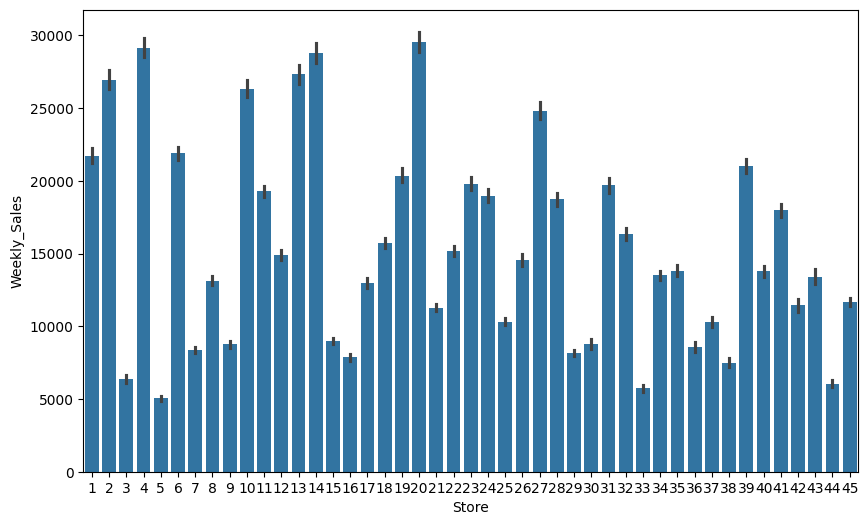

In [103]:
plt.figure(figsize=(10,6))
sns.barplot(x= 'Store',y='Weekly_Sales' ,data=train)
 

<Axes: xlabel='Dept', ylabel='Weekly_Sales'>

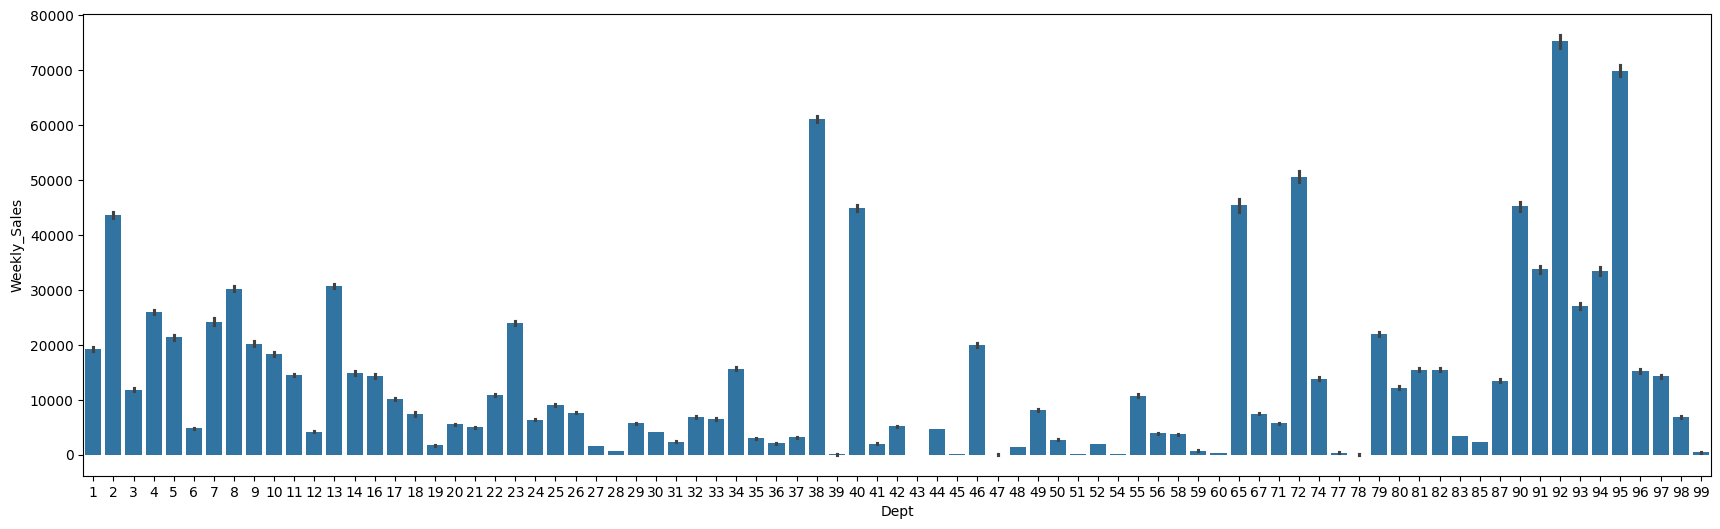

In [104]:
plt.figure(figsize=(21,6))
sns.barplot(x= 'Dept',y='Weekly_Sales' ,data=train)

o markdown pode ser substituido por 0 logo que pode significar que não teve promoção

Holy days

In [105]:
train['IsHoliday'] = [1 if x == True else 0 for x in train['IsHoliday']]

In [106]:
df = train.merge(features, on=['Store', 'Date'], how='inner').merge(stores, on=['Store'], how='inner')

In [107]:
df['Date'] = pd.to_datetime(df['Date'])
df['IsSuperbowl'] = df['Date'].apply(lambda x: 1 if (x.month == 2 and x.day in [8, 10, 11, 12]) else 0)
df['IsLaborDay'] = df['Date'].apply(lambda x: 1 if (x.month == 9 and x.day in [6, 7, 9, 10]) else 0)
df['Ischristmas'] = df['Date'].apply(lambda x: 1 if (x.month == 12 and x.day in [27, 28, 30, 31]) else 0)
df['IsThanksgiving'] = df['Date'].apply(lambda x: 1 if (x.month == 11 and x.day in [22, 23, 24, 25]) else 0)


In [108]:
df.describe()


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,IsSuperbowl,IsLaborDay,Ischristmas,IsThanksgiving
count,"421,570.00","421,570.00",421570,"421,570.00","421,570.00","421,570.00","421,570.00","150,681.00","111,248.00","137,091.00","134,967.00","151,432.00","421,570.00","421,570.00","421,570.00","421,570.00","421,570.00","421,570.00","421,570.00"
mean,22.20,44.26,2011-06-18 08:30:31.963375104,"15,981.26",0.07,60.09,3.36,"7,246.42","3,334.63","1,439.42","3,383.17","4,628.98",171.20,7.96,"136,727.92",0.02,0.02,0.01,0.01
min,1.00,1.00,2010-02-05 00:00:00,"-4,988.94",0.00,-2.06,2.47,0.27,-265.76,-29.10,0.22,135.16,126.06,3.88,"34,875.00",0.00,0.00,0.00,0.00
25%,11.00,18.00,2010-10-08 00:00:00,"2,079.65",0.00,46.68,2.93,"2,240.27",41.60,5.08,504.22,"1,878.44",132.02,6.89,"93,638.00",0.00,0.00,0.00,0.00
50%,22.00,37.00,2011-06-17 00:00:00,"7,612.03",0.00,62.09,3.45,"5,347.45",192.00,24.60,"1,481.31","3,359.45",182.32,7.87,"140,167.00",0.00,0.00,0.00,0.00
75%,33.00,74.00,2012-02-24 00:00:00,"20,205.85",0.00,74.28,3.74,"9,210.90","1,926.94",103.99,"3,595.04","5,563.80",212.42,8.57,"202,505.00",0.00,0.00,0.00,0.00
max,45.00,99.00,2012-10-26 00:00:00,"693,099.36",1.00,100.14,4.47,"88,646.76","104,519.54","141,630.61","67,474.85","108,519.28",227.23,14.31,"219,622.00",1.00,1.00,1.00,1.00
std,12.79,30.49,NaN,"22,711.18",0.26,18.45,0.46,"8,291.22","9,475.36","9,623.08","6,292.38","5,962.89",39.16,1.86,"60,980.58",0.14,0.14,0.12,0.08


<Axes: title={'center': 'Weekly Sales Distribution'}, ylabel='Frequency'>

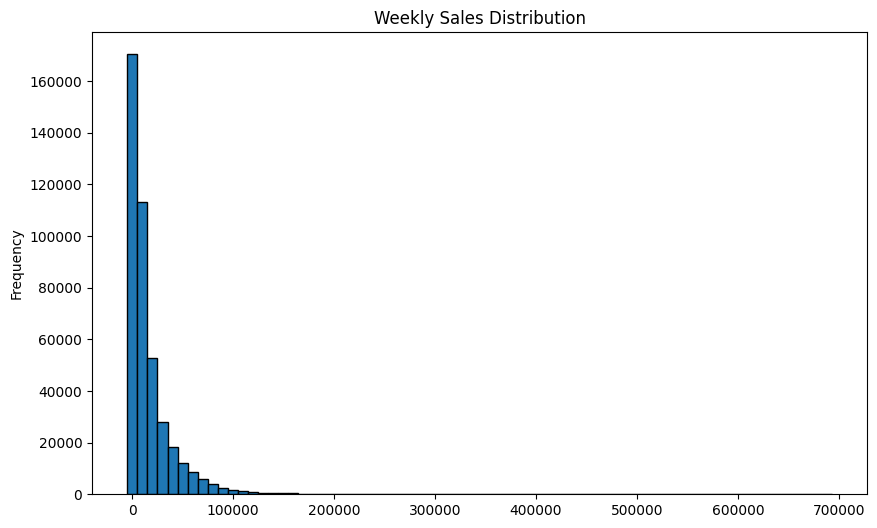

In [109]:
df['Weekly_Sales'].plot(kind='hist', figsize=(10, 6), title='Weekly Sales Distribution',bins=70, edgecolor='black')

<Axes: xlabel='IsThanksgiving', ylabel='Weekly_Sales'>

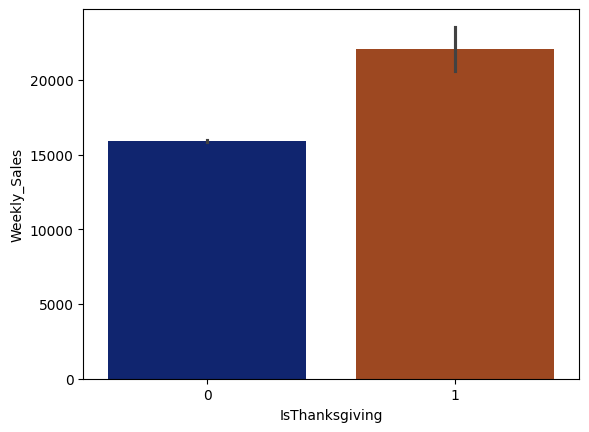

In [110]:
sns.barplot(x='IsThanksgiving', y='Weekly_Sales', data=df, palette='dark' )



<Axes: xlabel='Ischristmas', ylabel='Weekly_Sales'>

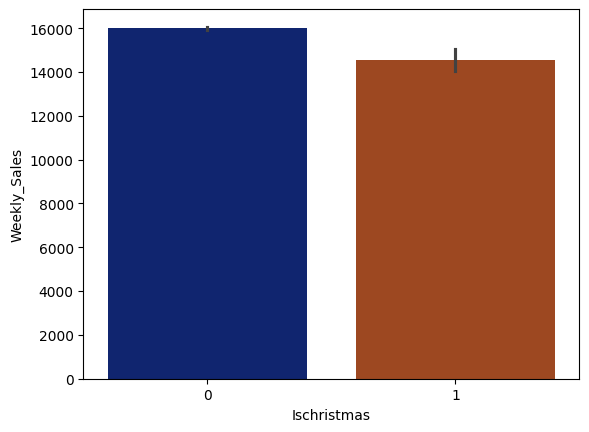

In [111]:
sns.barplot(x='Ischristmas', y='Weekly_Sales', data=df, palette='dark' )


<Axes: xlabel='IsLaborDay', ylabel='Weekly_Sales'>

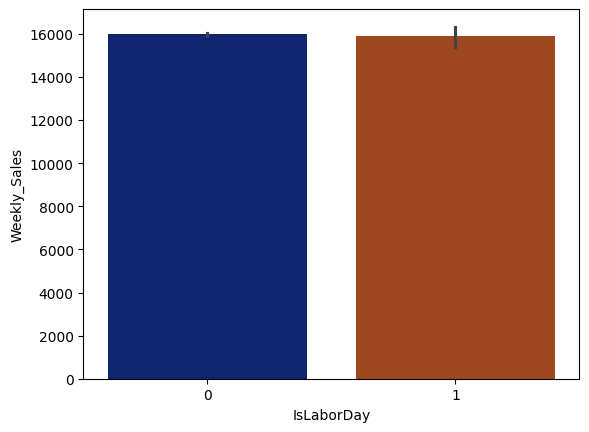

In [112]:
sns.barplot(x='IsLaborDay', y='Weekly_Sales', data=df, palette='dark')

<Axes: xlabel='IsSuperbowl', ylabel='Weekly_Sales'>

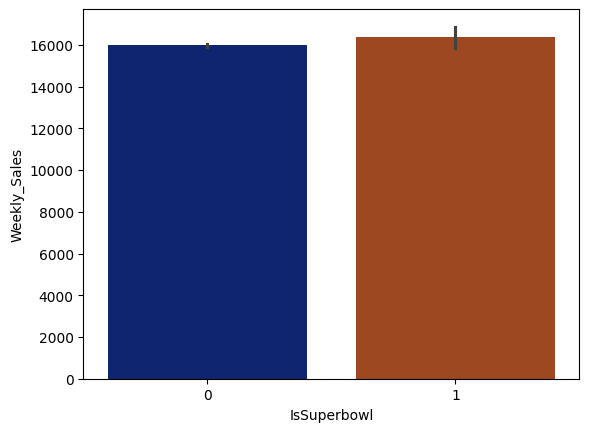

In [113]:
sns.barplot(x='IsSuperbowl', y='Weekly_Sales', data=df, palette='dark' )

<Axes: xlabel='Type'>

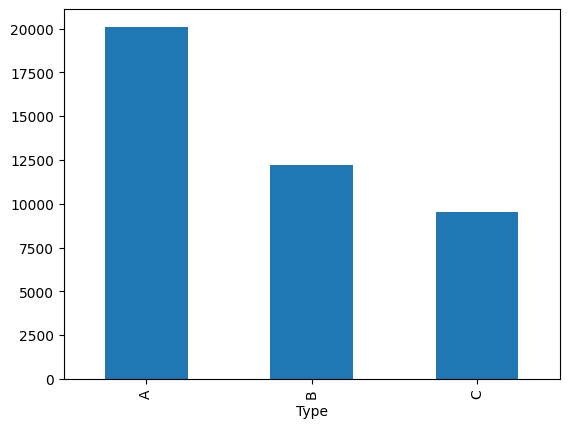

In [114]:
df.groupby('Type')['Weekly_Sales'].mean().plot(kind='bar')

<Axes: xlabel='Type', ylabel='Size'>

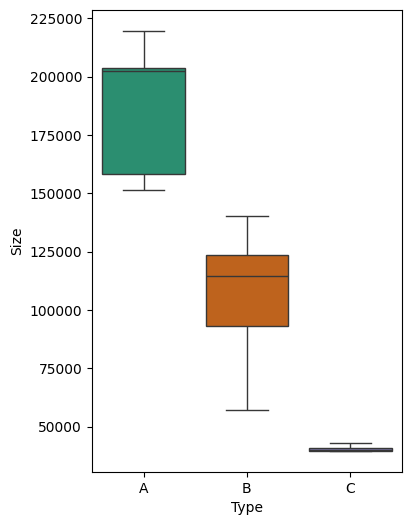

In [115]:
plt.figure(figsize=(4,6))
sns.boxplot(x='Type', y='Size', data=df, showfliers=False, palette='Dark2')

In [116]:
df.groupby('Type').describe()['Size']

,count,mean,min,25%,50%,75%,max,std
Type,,,,,,,,
A,"215,478.00","182,231.29","39,690.00","158,114.00","202,505.00","203,819.00","219,622.00","41,534.53"
B,"163,495.00","101,818.74","34,875.00","93,188.00","114,533.00","123,737.00","140,167.00","30,921.78"
C,"42,597.00","40,535.73","39,690.00","39,690.00","39,910.00","41,062.00","42,988.00","1,194.43"


In [117]:
df.Type = df.Type.map({'A': 1, 'B': 2, 'C': 3})

In [118]:
df = df.drop(['IsHoliday_y'], axis=1)
df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})

In [119]:
df = df.fillna(0)

<Axes: >

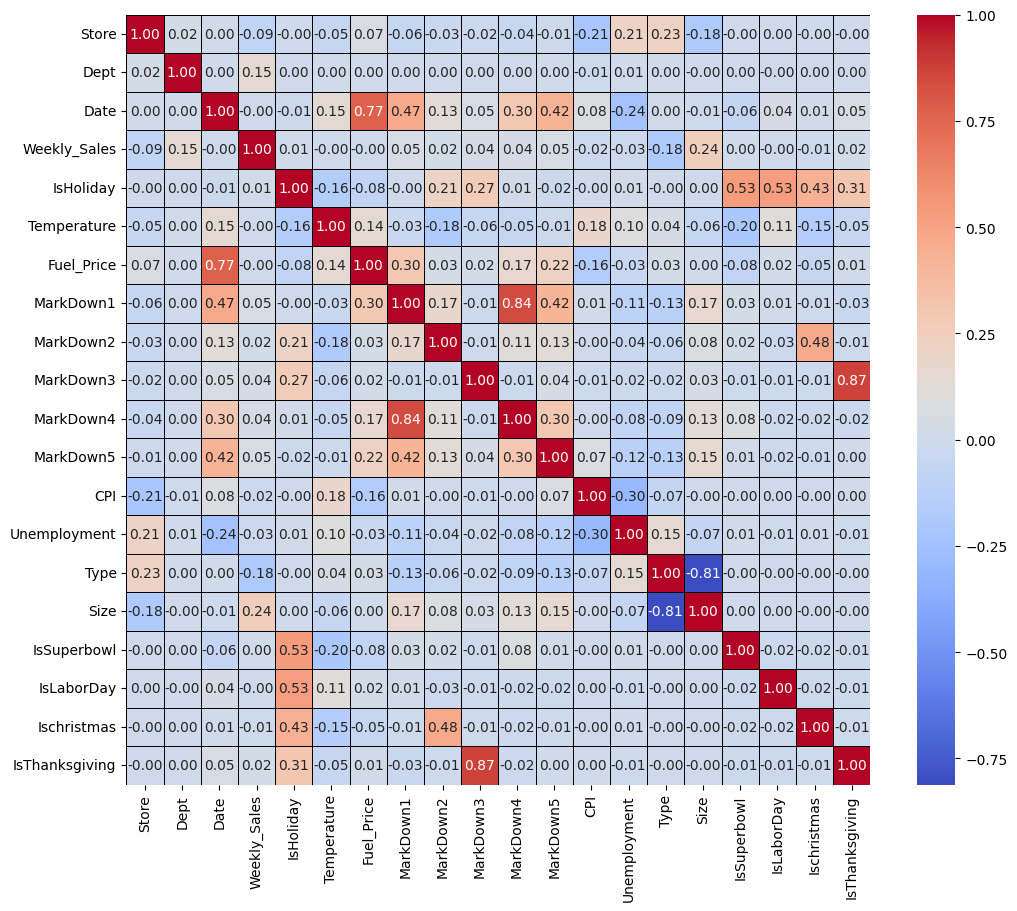

In [120]:
coor = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(coor, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, linecolor='black')

In [ ]:
df = df.drop(['Unemployment', 'CPI', 'MarkDown5', 'MarkDown4',  ], axis=1)

<Axes: >

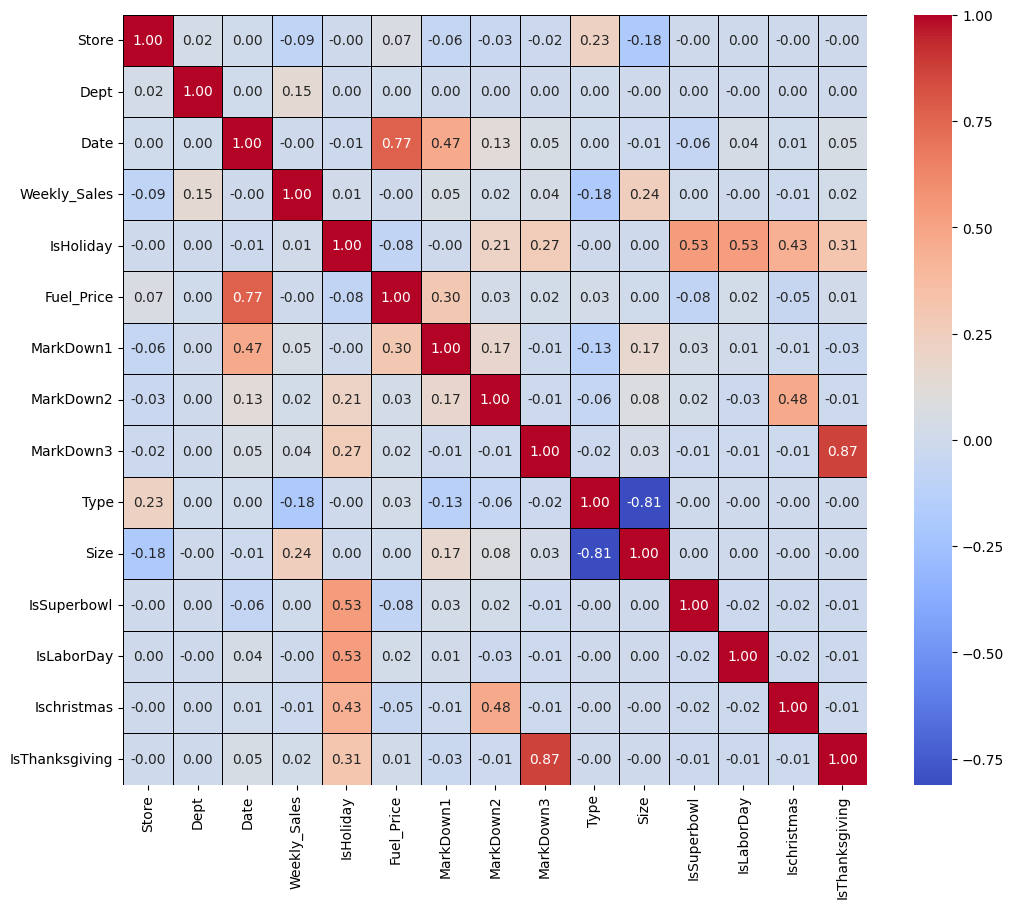

In [122]:
coor = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(coor, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, linecolor='black')

In [132]:
df = df.drop(['IsSuperbowl', 'IsLaborDay', 'Ischristmas', 'IsThanksgiving'], axis=1)

In [133]:
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month 
df['day'] = df['Date'].dt.day


In [134]:
train_data = df[:int(0.7*(len(df)))]
test_data = df[int(0.7*(len(df))):]

target = "Weekly_Sales"
used_cols = [c for c in df.columns.to_list() if c not in [target]] 

X_train = train_data[used_cols]
X_test = test_data[used_cols]
y_train = train_data[target]
y_test = test_data[target]

In [135]:

X_train = X_train.drop(['Date'], axis=1)
X_test = X_test.drop(['Date'], axis=1) 

In [139]:
def wmae_test(test, pred): # WMAE para test set
    weights = X_test['IsHoliday'].apply(lambda is_holiday:5 if is_holiday else 1)
    error = np.sum(weights * np.abs(test - pred), axis=0) / np.sum(weights)
    return error

In [147]:

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=50,
                           max_features = 'sqrt',min_samples_split = 10)

scaler=RobustScaler()

pipe = make_pipeline(scaler,rf)

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_train)

y_pred_test = pipe.predict(X_test)

In [148]:
wmae_test(y_test, y_pred_test)

np.float64(7131.777340416952)

In [129]:
X = df.drop(['Weekly_Sales', 'Date', 'Store', 'Dept'], axis=1)
y = df['Weekly_Sales']

In [130]:
df_test = test.merge(features, on=['Store', 'Date'], how='inner').merge(stores, on=['Store'], how='inner')

df_test['Date'] = pd.to_datetime(df_test['Date'])
df_test['year'] = df_test['Date'].dt.year
df_test['month'] = df_test['Date'].dt.month 
df_test['day'] = df_test['Date'].dt.day

df_test['IsHoliday_x'] = [1 if x == True else 0 for x in df_test['IsHoliday_x']]
df_test = df_test.rename(columns={'IsHoliday_x': 'IsHoliday'})
df_test = df_test.drop(['IsHoliday_y'], axis=1)

df_test['IsSuperbowl'] = df_test['Date'].apply(lambda x: 1 if (x.month == 2 and x.day in [8, 10, 11, 12]) else 0)
df_test['IsLaborDay'] = df_test['Date'].apply(lambda x: 1 if (x.month == 9 and x.day in [6, 7, 9, 10]) else 0)
df_test['Ischristmas'] = df_test['Date'].apply(lambda x: 1 if (x.month == 12 and x.day in [27, 28, 30, 31]) else 0)
df_test['IsThanksgiving'] = df_test['Date'].apply(lambda x: 1 if (x.month == 11 and x.day in [22, 23, 24, 25]) else 0)

df_test = df_test.drop(['Unemployment', 'CPI', 'MarkDown5', 'MarkDown4'], axis=1)

df_test['Type'] = df_test['Type'].map({'A': 1, 'B': 2, 'C': 3})
df_test = df_test.fillna(0)

In [131]:
df_test

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,Type,Size,year,month,day,IsSuperbowl,IsLaborDay,Ischristmas,IsThanksgiving
0,1,1,2012-11-02,0,55.32,3.39,"6,766.44","5,147.70",50.82,1,151315,2012,11,2,0,0,0,0
1,1,1,2012-11-09,0,61.24,3.31,"11,421.32","3,370.89",40.28,1,151315,2012,11,9,0,0,0,0
2,1,1,2012-11-16,0,52.92,3.25,"9,696.28",292.10,103.78,1,151315,2012,11,16,0,0,0,0
3,1,1,2012-11-23,1,56.23,3.21,883.59,4.17,"74,910.32",1,151315,2012,11,23,0,0,0,1
4,1,1,2012-11-30,0,52.34,3.21,"2,460.03",0.00,"3,838.35",1,151315,2012,11,30,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,0,76.05,3.64,"4,842.29",975.03,3.00,2,118221,2013,6,28,0,0,0,0
115060,45,98,2013-07-05,0,77.50,3.61,"9,090.48","2,268.58",582.74,2,118221,2013,7,5,0,0,0,0
115061,45,98,2013-07-12,0,79.37,3.61,"3,789.94","1,827.31",85.72,2,118221,2013,7,12,0,0,0,0
115062,45,98,2013-07-19,0,82.84,3.74,"2,961.49","1,047.07",204.19,2,118221,2013,7,19,0,0,0,0
